In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

In [3]:
import os 
from pathlib import Path 
path=Path.cwd().parent

In [4]:
(path/'data/train_flood.csv').exists()

True

In [5]:
df=pd.read_csv(path/'data/train_flood.csv')
df1=pd.read_csv(path/'data/test_flood.csv')

In [8]:
df.head()

,row_id,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,...,slope_scaled,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs
0,0,2,3,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,...,-0.564147,0.638676,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,51.435061
1,1,2,3,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,...,-0.184717,0.039940,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,565.028190
2,2,2,3,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,...,-0.564147,-1.066421,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,45.264231
3,3,2,3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,...,0.068236,2.278693,4.526986,-1.533821,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,402.916149
4,4,2,3,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,...,-0.311194,-0.728005,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2273.386393


In [9]:
df.shape

(2571055, 34)

In [10]:
df.columns

Index(['row_id', 'month', 'day_of_year', 'streamflow_today_cumecs',
       'streamflow_anomaly_zscore', 'flow_rate_of_change',
       'flow_velocity_km_per_day', 'antecedent_rain_3d_sum',
       'antecedent_rain_7d_sum', 'antecedent_rain_15d_sum',
       'antecedent_rain_30d_sum', 'antecedent_rain_60d', 'antecedent_rain_ewm',
       'rainfall_anomaly_zscore', 'upstream_rain_mean_scaled',
       'upstream_rain_weighted_scaled', 'upstream_rain_lagged_dist_sink',
       'soil_saturation_score', 'antecedent_saturation_interaction',
       'is_post_monsoon_saturated', 'monsoon_intensity',
       'monsoon_cumulative_rain', 'dist_to_outlet_scaled',
       'upstream_area_scaled', 'slope_scaled', 'slope_uav_scaled',
       'forest_cover_scaled', 'urban_cover_scaled',
       'rain_soilmoisture_interaction', 'rain_urban_interaction',
       'rain_slope_interaction', 'rain_basinsize_interaction',
       'uparea_rain_interaction', 'streamflow_tomorrow_cumecs'],
      dtype='object')

In [11]:
df.duplicated().sum(), df.isnull().sum()

(0,
 row_id                               0
 month                                0
 day_of_year                          0
 streamflow_today_cumecs              0
 streamflow_anomaly_zscore            0
 flow_rate_of_change                  0
 flow_velocity_km_per_day             0
 antecedent_rain_3d_sum               0
 antecedent_rain_7d_sum               0
 antecedent_rain_15d_sum              0
 antecedent_rain_30d_sum              0
 antecedent_rain_60d                  0
 antecedent_rain_ewm                  0
 rainfall_anomaly_zscore              0
 upstream_rain_mean_scaled            0
 upstream_rain_weighted_scaled        0
 upstream_rain_lagged_dist_sink       0
 soil_saturation_score                0
 antecedent_saturation_interaction    0
 is_post_monsoon_saturated            0
 monsoon_intensity                    0
 monsoon_cumulative_rain              0
 dist_to_outlet_scaled                0
 upstream_area_scaled                 0
 slope_scaled                       

In [6]:
df.describe()

,row_id,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,...,slope_scaled,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs
count,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,...,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06
mean,1.285527e+06,6.468311e+00,1.814878e+02,1.202081e+03,-1.193670e-01,1.091169e-02,1.164625e-15,1.282544e-02,2.492976e-02,4.362454e-02,...,-1.615960e-17,6.209861e-18,3.416806e-17,2.990379e-17,-3.449886e-16,2.312600e-16,3.015666e-16,-1.362798e-16,1.131096e-16,1.202092e+03
std,7.421998e+05,3.457065e+00,1.059191e+02,2.159559e+03,8.937900e-01,1.447007e+02,1.000000e+00,3.763439e-02,5.738691e-02,8.307907e-02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.159555e+03
min,0.000000e+00,1.000000e+00,1.000000e+00,1.116840e+01,-3.954120e+00,-3.008787e+03,-1.716099e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-5.641469e-01,-1.079437e+00,-3.472068e-01,-1.533821e+00,-5.180248e-01,-5.141787e-01,-5.141082e-01,-5.194928e-01,-4.722618e-01,1.116829e+01
25%,6.427635e+05,3.000000e+00,8.900000e+01,2.234027e+02,-7.327617e-01,-9.173950e+00,-6.070505e-01,0.000000e+00,0.000000e+00,0.000000e+00,...,-4.376703e-01,-8.581647e-01,-3.472068e-01,-7.976656e-01,-5.180248e-01,-5.141787e-01,-5.141082e-01,-5.194928e-01,-4.722618e-01,2.234089e+02
50%,1.285527e+06,6.000000e+00,1.810000e+02,4.884062e+02,-3.101673e-01,-1.442020e+00,-1.466658e-01,0.000000e+00,0.000000e+00,3.385531e-03,...,-3.111937e-01,-3.114925e-01,-3.472068e-01,-6.151009e-02,-5.180248e-01,-5.141787e-01,-5.141082e-01,-5.194928e-01,-4.722618e-01,4.884243e+02
75%,1.928290e+06,9.000000e+00,2.730000e+02,1.251528e+03,3.326277e-01,1.159555e+00,6.132338e-01,4.617780e-03,2.020516e-02,4.744089e-02,...,6.823608e-02,8.469320e-01,-2.079442e-01,4.292602e-01,-5.180248e-01,-5.141787e-01,-5.141082e-01,-5.194928e-01,-4.722618e-01,1.251533e+03
max,2.571054e+06,1.200000e+01,3.650000e+02,3.161156e+04,4.651924e+00,1.058047e+04,1.855602e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,8.542168e+00,2.278693e+00,9.261916e+00,5.582348e+00,2.015445e+00,2.080001e+00,2.048386e+00,1.962240e+00,2.136097e+00,3.161156e+04


In [12]:
Id=df1['row_id']

In [13]:
df.drop('row_id',axis=1,inplace=True)
df1.drop('row_id',axis=1,inplace=True)

In [14]:
df.head()

,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,antecedent_rain_30d_sum,...,slope_scaled,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs
0,2,3,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,0.0,...,-0.564147,0.638676,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,51.435061
1,2,3,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,0.0,...,-0.184717,0.039940,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,565.028190
2,2,3,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,0.0,...,-0.564147,-1.066421,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,45.264231
3,2,3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,0.0,...,0.068236,2.278693,4.526986,-1.533821,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,402.916149
4,2,3,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,0.0,...,-0.311194,-0.728005,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2273.386393


In [15]:
df['month_cos'] = np.cos(2*np.pi*df['month']/12 )
df['month_sin'] = np.sin(2*np.pi*df['month']/12 )

df1['month_cos'] = np.cos(2*np.pi*df1['month']/12 )
df1['month_sin'] = np.sin(2*np.pi*df1['month']/12 )

In [16]:
df.drop('month',axis=1,inplace=True)
df1.drop('month',axis=1,inplace=True)

In [17]:
df['dayofyear_cos'] = np.cos(2*np.pi*df['day_of_year']/365 )
df['dayofyear_sin'] = np.sin(2*np.pi*df['day_of_year']/365)

df1['dayofyear_cos'] = np.cos(2*np.pi*df1['day_of_year']/365 )
df1['dayofyear_sin'] = np.sin(2*np.pi*df1['day_of_year']/365)

In [18]:
df.drop('day_of_year',axis=1,inplace=True)
df1.drop('day_of_year',axis=1,inplace=True)

In [9]:
df.sample(5)

,row_id,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,...,slope_scaled,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs
1208620,1208620,2,8,244.16278,0.986758,-2.624450,-0.146666,0.000000,0.000000,0.000000,...,-0.311194,-1.053405,-0.347207,-0.061510,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,241.538219
194645,194645,7,167,291.37110,0.647494,15.566920,-0.256761,0.000000,0.000000,0.026657,...,-0.311194,-0.285460,-0.347207,1.901571,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,306.937904
2201216,2201216,7,156,216.74214,-0.986155,-4.009780,0.613234,0.000000,0.026695,0.033385,...,0.068236,-0.103236,-0.347207,1.901571,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,212.732249
1682604,1682604,8,204,1177.52670,-1.355625,-18.664900,-0.146666,0.175245,0.201070,0.285927,...,-0.311194,-0.025140,-0.347207,0.429260,1.985900,2.064335,2.033185,1.946107,2.129171,1158.861693
2483249,2483249,8,194,96.53236,-0.618153,21.030865,-1.649524,0.000000,0.000000,0.022022,...,-0.564147,-1.066421,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,117.563108


In [20]:
import matplotlib.pyplot as plt 

In [21]:
# single merged interaction
df['merged_rain_interaction'] = df[[
    'rain_soilmoisture_interaction', 
    'rain_urban_interaction', 
    'rain_slope_interaction', 
    'rain_basinsize_interaction',
    'uparea_rain_interaction',
    'antecedent_saturation_interaction'
]].mean(axis=1)

df1['merged_rain_interaction'] = df1[[
    'rain_soilmoisture_interaction', 
    'rain_urban_interaction', 
    'rain_slope_interaction', 
    'rain_basinsize_interaction',
    'uparea_rain_interaction',
    'antecedent_saturation_interaction'
]].mean(axis=1)

In [22]:
# single merged scaled
df['upstream_rain_weighted' ]=(df['upstream_rain_mean_scaled']*0.6)+(df['upstream_rain_weighted_scaled']*0.4)
df1['upstream_rain_weighted' ]=(df1['upstream_rain_mean_scaled']*0.6)+(df1['upstream_rain_weighted_scaled']*0.4)

In [23]:
drop_cols=[
    'rain_soilmoisture_interaction', 
    'rain_urban_interaction', 
    'rain_slope_interaction', 
    'rain_basinsize_interaction',
    'uparea_rain_interaction',
    'antecedent_saturation_interaction',
    
    'upstream_rain_mean_scaled',
    'upstream_rain_weighted_scaled'
]

In [24]:
df.drop(columns=drop_cols,inplace=True)
df1.drop(columns=drop_cols,inplace=True)
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,antecedent_rain_30d_sum,antecedent_rain_60d,antecedent_rain_ewm,...,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin,merged_rain_interaction,upstream_rain_weighted
0,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,0.0,0.0,0.0,...,0.638676,-0.347207,-1.043051,51.435061,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
1,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,0.0,0.0,0.0,...,0.039940,-0.347207,0.183875,565.028190,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
2,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.066421,-0.347207,-1.043051,45.264231,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,0.0,0.0,0.0,...,2.278693,4.526986,-1.533821,402.916149,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
4,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.728005,-0.347207,0.183875,2273.386393,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854


In [25]:
df.drop('flow_rate_of_change',axis=1, inplace= True)
df1.drop('flow_rate_of_change',axis=1,inplace=True)

In [26]:
# giving higher weight to recent rain
df['antecedent_total'] = (df['antecedent_rain_3d_sum'] * 0.4) + (df['antecedent_rain_7d_sum'] * 0.3) + (df['antecedent_rain_15d_sum'] * 0.1)+(df['antecedent_rain_30d_sum']*0.05)+(df['antecedent_rain_60d']*0.05)+(df['antecedent_rain_ewm']*0.1)
df1['antecedent_total'] = (df1['antecedent_rain_3d_sum'] * 0.4) + (df1['antecedent_rain_7d_sum'] * 0.3) + (df1['antecedent_rain_15d_sum'] * 0.1)+(df1['antecedent_rain_30d_sum']*0.05)+(df1['antecedent_rain_60d']*0.05)+(df1['antecedent_rain_ewm']*0.1)

In [27]:
antecedent_cols=[
    'antecedent_rain_3d_sum',
    'antecedent_rain_7d_sum',
    'antecedent_rain_15d_sum',
    'antecedent_rain_30d_sum',
    'antecedent_rain_60d',
    'antecedent_rain_ewm' 
]

In [28]:
df.drop(columns=antecedent_cols,inplace=True)
df1.drop(columns=antecedent_cols,inplace=True)
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_velocity_km_per_day,rainfall_anomaly_zscore,upstream_rain_lagged_dist_sink,soil_saturation_score,is_post_monsoon_saturated,monsoon_intensity,monsoon_cumulative_rain,dist_to_outlet_scaled,...,forest_cover_scaled,urban_cover_scaled,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin,merged_rain_interaction,upstream_rain_weighted,antecedent_total
0,51.84180,-0.554512,-1.649524,-0.274649,-0.231412,0.0,0,0.0,0.0,1.393736,...,-0.347207,-1.043051,51.435061,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
1,570.75726,-0.594236,0.206959,-0.220278,-0.231412,0.0,0,0.0,0.0,0.114867,...,-0.347207,0.183875,565.028190,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
2,45.45640,-1.113376,-1.649524,-0.311483,-0.231412,0.0,0,0.0,0.0,-1.348137,...,-0.347207,-1.043051,45.264231,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
3,405.39710,-0.729036,0.769118,-0.228279,-0.231412,0.0,0,0.0,0.0,-0.265436,...,4.526986,-1.533821,402.916149,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
4,2289.59030,-1.284924,-0.256761,-0.282414,-0.231412,0.0,0,0.0,0.0,-1.402705,...,-0.347207,0.183875,2273.386393,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0


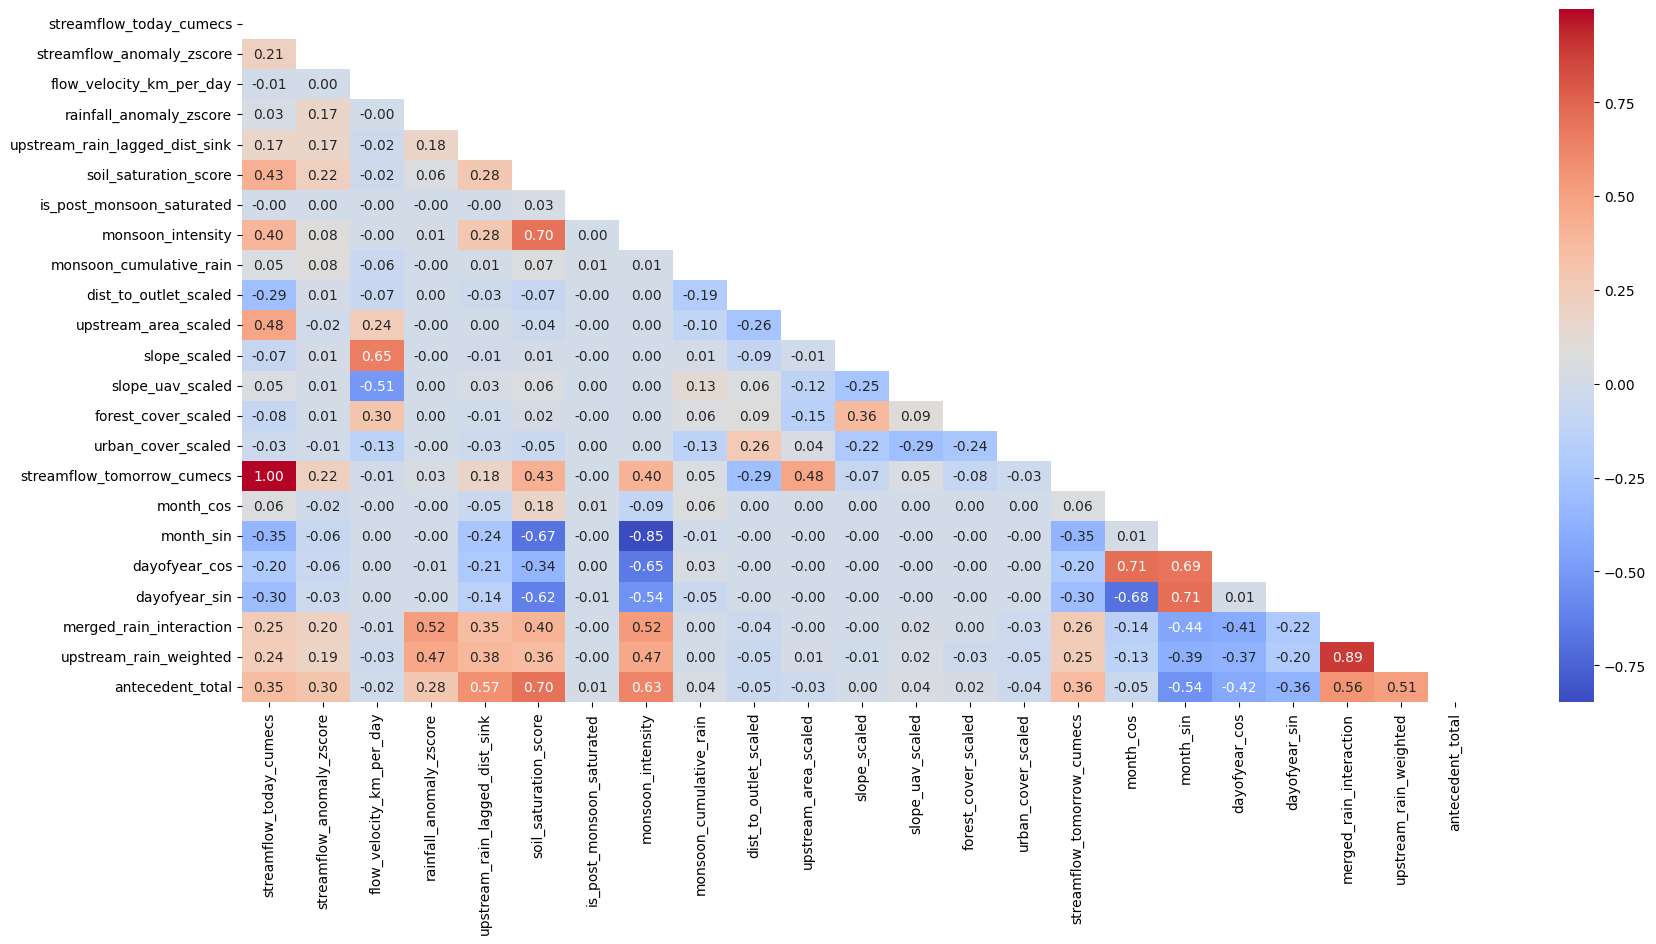

In [29]:
plt.figure(figsize=(20,9))
cor = df.corr()
sns.heatmap(cor,annot=True,fmt='.2f',cmap='coolwarm',mask=np.triu(np.ones_like(cor,dtype=bool),k=0))
plt.show()

In [30]:
df['merged_upstream']=(df['merged_rain_interaction']*0.6)+(df['upstream_rain_weighted']*0.4)
df1['merged_upstream']=(df1['merged_rain_interaction']*0.6)+(df1['upstream_rain_weighted']*0.4)

In [31]:
df.drop(columns={'merged_rain_interaction','upstream_rain_weighted'},axis=1,inplace=True)
df1.drop(columns={'merged_rain_interaction','upstream_rain_weighted'},axis=1,inplace=True)
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_velocity_km_per_day,rainfall_anomaly_zscore,upstream_rain_lagged_dist_sink,soil_saturation_score,is_post_monsoon_saturated,monsoon_intensity,monsoon_cumulative_rain,dist_to_outlet_scaled,...,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin,antecedent_total,merged_upstream
0,51.84180,-0.554512,-1.649524,-0.274649,-0.231412,0.0,0,0.0,0.0,1.393736,...,0.638676,-0.347207,-1.043051,51.435061,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
1,570.75726,-0.594236,0.206959,-0.220278,-0.231412,0.0,0,0.0,0.0,0.114867,...,0.039940,-0.347207,0.183875,565.028190,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
2,45.45640,-1.113376,-1.649524,-0.311483,-0.231412,0.0,0,0.0,0.0,-1.348137,...,-1.066421,-0.347207,-1.043051,45.264231,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
3,405.39710,-0.729036,0.769118,-0.228279,-0.231412,0.0,0,0.0,0.0,-0.265436,...,2.278693,4.526986,-1.533821,402.916149,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
4,2289.59030,-1.284924,-0.256761,-0.282414,-0.231412,0.0,0,0.0,0.0,-1.402705,...,-0.728005,-0.347207,0.183875,2273.386393,0.5,0.866025,0.998667,0.05162,0.0,-0.437748


In [32]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [33]:
X=df.drop('streamflow_tomorrow_cumecs',axis=1)
y=df['streamflow_tomorrow_cumecs']

In [34]:
split=int(df.shape[0]*0.8)

In [35]:
train=df.iloc[:split]
test=df.iloc[split:]

In [36]:
X_train=train.drop('streamflow_tomorrow_cumecs',axis=1)
y_train=train['streamflow_tomorrow_cumecs']

X_test=test.drop('streamflow_tomorrow_cumecs',axis=1)
y_test=test['streamflow_tomorrow_cumecs']

# Base error 

In [37]:
base=X_test['streamflow_today_cumecs']
mean_absolute_error(y_test,base),mean_squared_error(y_test,base)**.5,  r2_score(y_test, base)

(43.755939854379925, 140.80993250221957, 0.9956920809424377)

In [38]:
from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor 
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge


In [ ]:
models  = {
    'xgb' : XGBRegressor(
        n_estimators = 200,
        subsample = 0.75,
        max_depth = 8,
        n_jobs= -1,
        device= 'cuda'
        ),
    'Linear_Regression' : LinearRegression(n_jobs=-1),
    'Ridge':Ridge(),
    'RandomForestRegressor':RandomForestRegressor(
        n_estimators = 300,
        max_depth=10,
        max_samples=.4,
        n_jobs=-1,
    ),
    'Catboost':CatBoostRegressor(
        iterations=400,
        depth=15,
        learning_rate=0.1,
        task_type="GPU",    
    )
}

In [88]:
def training(Model, X_train,y_train,X_test,y_test):
    result = []
    saved_model = {}
    import time 
    
    for name,model in Model.items():
        start = time.perf_counter()
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        
        mae = mean_absolute_error(y_test,y_pred)
        mse = mean_squared_error(y_test,y_pred)
        r2 = r2_score(y_test,y_pred)
        end = time.perf_counter()
        result.append({
            'model':name,
            'MAE':mae,
            "RMSE":mse**0.5,
            'R2_score/NSE':r2,
            'Time_taken(s)' : end- start
        })
        saved_model[name]=model
    return pd.DataFrame(result), saved_model

In [89]:
result,saved_model = training(models ,X_train,y_train,X_test,y_test)

0:	learn: 1953.1271036	total: 107ms	remaining: 42.7s
1:	learn: 1763.3590642	total: 205ms	remaining: 40.8s
2:	learn: 1592.2441660	total: 299ms	remaining: 39.6s
3:	learn: 1438.9608477	total: 394ms	remaining: 39s
4:	learn: 1300.2980098	total: 490ms	remaining: 38.7s
5:	learn: 1176.0733293	total: 589ms	remaining: 38.7s
6:	learn: 1064.8202169	total: 686ms	remaining: 38.5s
7:	learn: 964.3275039	total: 778ms	remaining: 38.1s
8:	learn: 873.2692088	total: 884ms	remaining: 38.4s
9:	learn: 791.7675055	total: 987ms	remaining: 38.5s
10:	learn: 718.7939399	total: 1.08s	remaining: 38.4s
11:	learn: 652.9739044	total: 1.18s	remaining: 38.2s
12:	learn: 593.6606604	total: 1.28s	remaining: 38s
13:	learn: 540.7136284	total: 1.37s	remaining: 37.8s
14:	learn: 493.2178538	total: 1.47s	remaining: 37.7s
15:	learn: 450.8253780	total: 1.57s	remaining: 37.6s
16:	learn: 412.8368245	total: 1.66s	remaining: 37.5s
17:	learn: 378.8480590	total: 1.76s	remaining: 37.4s
18:	learn: 348.5878899	total: 1.86s	remaining: 37.2s


In [ ]:
# Base error 
pd.DataFrame({
    'MAE': [mean_absolute_error(y_test,base)],
    'RMSE' :[mean_squared_error(y_test,base)**.5],
    'R2_score/NSE' : [r2_score(y_test, base)]
    })

,MAE,RMSE,R2_score/NSE
0,43.75594,140.809933,0.995692


In [90]:
result

,model,MAE,RMSE,R2_score/NSE,Time_taken(s)
0,xgb,30.421507,99.486147,0.997850,3.040383
1,Linear_Regression,48.888301,136.831646,0.995932,2.646351
2,Ridge,48.888495,136.831833,0.995932,0.328762
3,RandomForestRegressor,39.470180,128.696042,0.996401,309.494954
4,Catboost,34.564228,95.505659,0.998018,45.968747


In [91]:
result.sort_values('MAE')

,model,MAE,RMSE,R2_score/NSE,Time_taken(s)
0,xgb,30.421507,99.486147,0.997850,3.040383
4,Catboost,34.564228,95.505659,0.998018,45.968747
3,RandomForestRegressor,39.470180,128.696042,0.996401,309.494954
1,Linear_Regression,48.888301,136.831646,0.995932,2.646351
2,Ridge,48.888495,136.831833,0.995932,0.328762


In [ ]:
best_model = saved_model['xgb'] # G the chosen one 

In [94]:
(pd.Series((best_model.feature_importances_), index = X_train.columns).sort_values(ascending= False) )

streamflow_today_cumecs           0.963738
monsoon_intensity                 0.014480
dist_to_outlet_scaled             0.005477
streamflow_anomaly_zscore         0.004146
dayofyear_cos                     0.002229
month_cos                         0.001711
upstream_area_scaled              0.001651
slope_uav_scaled                  0.000891
dayofyear_sin                     0.000740
merged_upstream                   0.000695
monsoon_cumulative_rain           0.000684
urban_cover_scaled                0.000515
month_sin                         0.000499
antecedent_total                  0.000448
slope_scaled                      0.000419
upstream_rain_lagged_dist_sink    0.000346
flow_velocity_km_per_day          0.000344
forest_cover_scaled               0.000340
soil_saturation_score             0.000339
rainfall_anomaly_zscore           0.000277
is_post_monsoon_saturated         0.000030
dtype: float32

<Axes: >

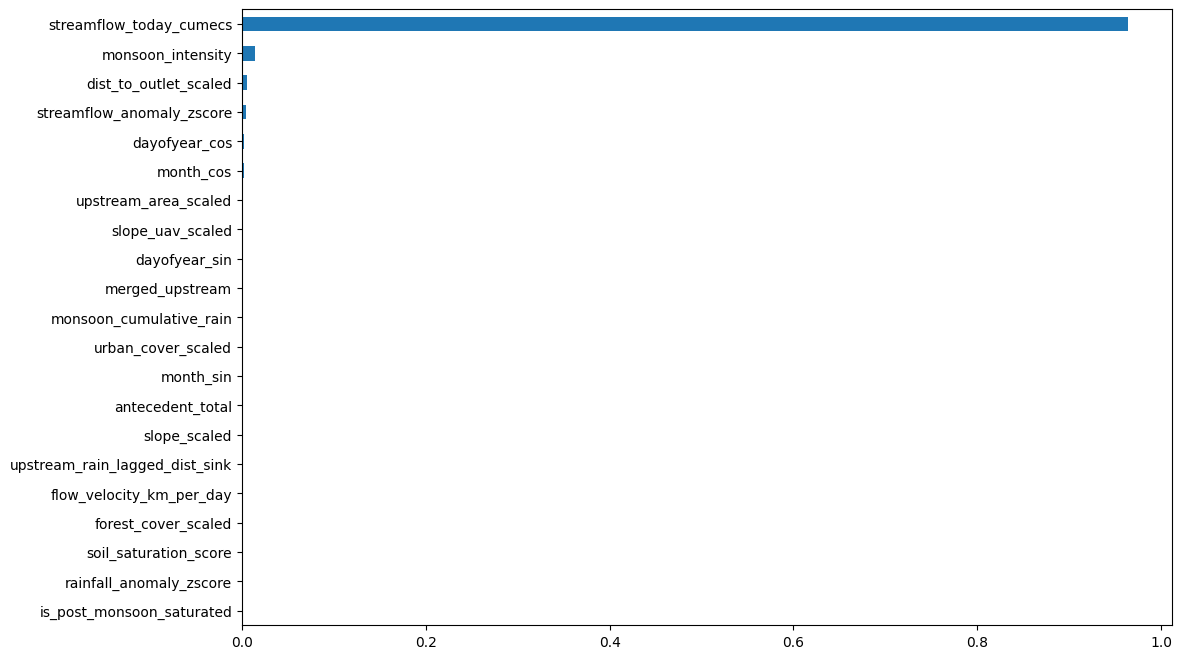

In [95]:
plt.figure(figsize = (12,8))
(pd.Series((best_model.feature_importances_), index = X_train.columns).sort_values() ).plot(kind= 'barh')

In [96]:
import joblib 
joblib.dump(best_model,'Xgb_model.pkl')

['Xgb_model.pkl']

In [102]:
result.sort_values('MAE')

,model,MAE,RMSE,R2_score/NSE,Time_taken(s)
0,xgb,30.421507,99.486147,0.997850,3.040383
4,Catboost,34.564228,95.505659,0.998018,45.968747
3,RandomForestRegressor,39.470180,128.696042,0.996401,309.494954
1,Linear_Regression,48.888301,136.831646,0.995932,2.646351
2,Ridge,48.888495,136.831833,0.995932,0.328762


In [98]:
sols=best_model.predict(df1)
sols1=saved_model['Catboost'].predict(df1)
sols2=saved_model['RandomForestRegressor'].predict(df1)

In [ ]:
final_sol=(sols*0.5)+(sols1*0.3)+(sols2*0.2)#ensembling 

In [107]:
submission=pd.DataFrame({
    'row_id':Id,
    'streamflow_tomorrow_cumecs':final_sol
})

In [108]:
submission.to_csv('submission.csv',index=False)